In [1]:
import pandas as pd

dataset = pd.read_csv("Student Performance.csv")
print(dataset.head())

   student_id  age gender academic_level  study_hours  self_study_hours  \
0           1   18  Other    High School         7.64              1.56   
1           2   18  Other    High School         2.21              2.22   
2           3   22   Male    High School         3.45              0.00   
3           4   17  Other    High School         5.75              2.08   
4           5   19  Other    High School         6.83              1.72   

   online_classes_hours  social_media_hours  gaming_hours  sleep_hours  ...  \
0                  2.20                3.05          2.19         6.52  ...   
1                  2.10                1.65          2.55         5.97  ...   
2                  0.29                1.34          2.08         8.39  ...   
3                  3.01                2.27          2.20         6.31  ...   
4                  3.33                2.65          0.70         8.01  ...   

   exercise_minutes  caffeine_intake_mg  part_time_job  upcoming_deadline 

In [4]:
dataset = dataset.fillna(dataset.mean(numeric_only=True))

In [2]:
print(dataset.isnull().sum())

student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64


In [5]:
y = dataset['exam_score']

In [6]:
X = dataset[['study_hours',
             'sleep_hours',
             'mental_health_score',
             'focus_index',
             'burnout_level']]

In [11]:
dataset = dataset.drop("student_id", axis=1)

In [12]:
Q1 = dataset.quantile(0.25, numeric_only=True)
Q3 = dataset.quantile(0.75, numeric_only=True)

IQR = Q3 - Q1

print(IQR)

age                       5.0000
study_hours               2.5100
self_study_hours          1.6300
online_classes_hours      1.3700
social_media_hours        2.0400
gaming_hours              1.6700
sleep_hours               1.5725
screen_time_hours         3.4300
exercise_minutes         75.0000
caffeine_intake_mg      247.0000
part_time_job             1.0000
upcoming_deadline         1.0000
mental_health_score       5.0000
focus_index              13.6750
burnout_level            19.6250
productivity_score       23.8525
exam_score               18.0625
dtype: float64


In [18]:
numeric_data = dataset.select_dtypes(include=['number'])
print(numeric_data.head())

   age  study_hours  self_study_hours  online_classes_hours  \
0   18         7.64              1.56                  2.20   
1   18         2.21              2.22                  2.10   
2   22         3.45              0.00                  0.29   
3   17         5.75              2.08                  3.01   
4   19         6.83              1.72                  3.33   

   social_media_hours  gaming_hours  sleep_hours  screen_time_hours  \
0                3.05          2.19         6.52               6.47   
1                1.65          2.55         5.97               6.05   
2                1.34          2.08         8.39               7.62   
3                2.27          2.20         6.31              11.67   
4                2.65          0.70         8.01              10.02   

   exercise_minutes  caffeine_intake_mg  part_time_job  upcoming_deadline  \
0                81                  38              1                  0   
1               111                 339 

In [21]:
outliers = numeric_data[
    ((numeric_data < (Q1 - 1.5 * IQR)) |
     (numeric_data > (Q3 + 1.5 * IQR))).any(axis=1)
]

print(outliers)

      age  study_hours  self_study_hours  online_classes_hours  \
20     23         9.31              4.04                  3.06   
33     22         0.00              1.22                  2.26   
269    23         3.32              1.33                  0.77   
270    21         8.55              2.60                  3.12   
292    18         0.70              5.80                  2.37   
...   ...          ...               ...                   ...   
4799   19         1.62              6.52                  3.50   
4864   19         3.07              2.79                  3.98   
4902   25         7.33              0.00                  1.38   
4905   24         5.47              2.32                  1.89   
4986   20         8.88              0.50                  2.03   

      social_media_hours  gaming_hours  sleep_hours  screen_time_hours  \
20                  1.46          1.23         7.74               2.90   
33                  7.11          2.18         8.33        

In [22]:
outliers = outliers.drop_duplicates()

print(outliers.shape)

(140, 17)


In [23]:
dataset_cleaned = numeric_data.drop(outliers.index)

print(dataset_cleaned.shape)

(4860, 17)


In [24]:
print("Original dataset shape:", numeric_data.shape)
print("After removing outliers:", dataset_cleaned.shape)

Original dataset shape: (5000, 17)
After removing outliers: (4860, 17)


In [27]:
X = dataset_cleaned.drop("exam_score", axis=1)

In [28]:
y = dataset_cleaned["exam_score"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3888, 16)
(972, 16)
(3888,)
(972,)


In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
regressor = LinearRegression()

In [32]:
regressor.fit(X_train, y_train)

LinearRegression()

In [33]:
y_pred_lr = regressor.predict(X_test)

print(y_pred_lr)

[ 2.97362920e+01  1.13276948e+01  6.24115182e+00  3.01213090e+01
  9.00546744e+00  1.29709180e+01  1.30620759e+01  9.17648302e+00
  2.89319204e+01  1.14569519e+01  2.80055381e+01  5.40486621e+00
  1.54548048e+01  2.36386852e+01  6.23451951e-01 -1.29965762e+00
  2.54514240e+01  8.06321597e+00  1.94590123e+01  2.73351840e+01
  3.95511430e+00  2.66655536e+01  2.85466338e+01  1.92004628e+01
  8.73083559e+00  3.85253114e+01  2.30994401e+01  8.36360846e+00
  4.00089254e+01  2.07770369e+01  6.08953390e+00  6.32481900e+00
  2.17635203e+01  9.52775771e+00  3.27917687e+01  1.50940928e+01
  8.22272402e+00  2.08315599e+01  1.95398042e+01  5.05658075e+00
  1.90548403e+00  1.95560397e+01  9.06687251e+00  1.69016651e+01
  1.01198873e+01  1.73076887e+01 -3.59290439e+00  2.52586760e+01
  2.50538064e+01  1.77329774e+01  2.64040731e+01  3.42639457e+01
  3.30896459e+01  2.39567859e+01  3.07381812e+01  1.91778475e+01
  2.97075815e+01  3.51958626e+01  1.69271000e+01  3.80569130e+01
  1.54959428e+01  2.34802

In [34]:
from sklearn.metrics import mean_squared_error, r2_score

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("MSE:", mse_lr)
print("R2 Score:", r2_lr)

MSE: 23.544480640924245
R2 Score: 0.8324161383173782


In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [36]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [37]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [38]:
y_pred_poly = poly_model.predict(X_test_poly)

print(y_pred_poly)

[ 3.05283388e+01  1.08725413e+01  5.74925367e+00  3.13691164e+01
  9.38583721e+00  1.15957410e+01  1.24089527e+01  8.74627648e+00
  2.92936960e+01  1.20561997e+01  2.70533491e+01  8.42503290e+00
  1.61688894e+01  2.36064049e+01  2.67373469e+00  8.20804428e-01
  2.55913588e+01  8.70996781e+00  1.82317542e+01  2.84954636e+01
  3.33714790e+00  2.62768192e+01  2.91674159e+01  1.86236480e+01
  9.18013224e+00  3.93741733e+01  2.26396149e+01  7.93231584e+00
  4.13803157e+01  2.00334978e+01  5.70329195e+00  7.35459753e+00
  2.20075442e+01  9.25802724e+00  3.25855586e+01  1.33001020e+01
  8.47530534e+00  2.08146724e+01  1.85689341e+01  5.41271766e+00
  2.93119707e+00  1.79726562e+01  1.00156574e+01  1.64460035e+01
  9.22840702e+00  1.62149429e+01 -9.67866691e-01  2.61840570e+01
  2.39499196e+01  1.66169863e+01  2.51594214e+01  3.47072797e+01
  3.23644875e+01  2.38197910e+01  3.06110093e+01  1.80460312e+01
  2.87628272e+01  3.52018155e+01  1.57666143e+01  4.05515759e+01
  1.52211067e+01  2.29796

In [39]:
from sklearn.metrics import mean_squared_error, r2_score

mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("MSE:", mse_poly)
print("R2 Score:", r2_poly)

MSE: 23.745884628790467
R2 Score: 0.8309825939313434


In [40]:
from sklearn.linear_model import Ridge

In [41]:
ridge = Ridge()

In [42]:
ridge.fit(X_train, y_train)

Ridge()

In [43]:
y_pred_ridge = ridge.predict(X_test)

print(y_pred_ridge)

[ 2.97361205e+01  1.13278981e+01  6.24109581e+00  3.01210766e+01
  9.00570637e+00  1.29710319e+01  1.30617340e+01  9.17667492e+00
  2.89318225e+01  1.14568444e+01  2.80057547e+01  5.40511461e+00
  1.54548862e+01  2.36383832e+01  6.23442385e-01 -1.29981178e+00
  2.54514173e+01  8.06308145e+00  1.94592260e+01  2.73349917e+01
  3.95510639e+00  2.66655904e+01  2.85467483e+01  1.92002580e+01
  8.73120851e+00  3.85253352e+01  2.30993542e+01  8.36355069e+00
  4.00088519e+01  2.07768671e+01  6.08932831e+00  6.32480900e+00
  2.17634769e+01  9.52759314e+00  3.27914135e+01  1.50941912e+01
  8.22303249e+00  2.08314432e+01  1.95399934e+01  5.05632456e+00
  1.90537819e+00  1.95562259e+01  9.06684255e+00  1.69015647e+01
  1.01198192e+01  1.73077888e+01 -3.59299946e+00  2.52587486e+01
  2.50537535e+01  1.77329756e+01  2.64039798e+01  3.42640419e+01
  3.30896428e+01  2.39569650e+01  3.07380112e+01  1.91779806e+01
  2.97073656e+01  3.51958170e+01  1.69272723e+01  3.80567060e+01
  1.54958391e+01  2.34799

In [44]:
from sklearn.metrics import mean_squared_error, r2_score

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MSE:", mse_ridge)
print("R2 Score:", r2_ridge)

MSE: 23.544453975168462
R2 Score: 0.8324163281177138


In [45]:
from sklearn.linear_model import Lasso

In [46]:
lasso = Lasso()

In [47]:
lasso.fit(X_train, y_train)

Lasso()

In [48]:
y_pred_lasso = lasso.predict(X_test)

print(y_pred_lasso)

[ 29.61558363  11.5730758    6.36185951  29.66165287   9.80603385
  13.3914085   12.72553921   9.6492014   28.70433677  11.21440246
  28.28814944   5.7484181   15.74124479  23.59995198   0.63647767
  -1.44629123  25.09323973   7.88762681  19.88710339  27.21698799
   4.12616241  26.40961028  28.42893465  19.06484391   9.38344802
  38.04776668  22.75721854   8.62959153  39.62299389  20.7157759
   6.08165045   6.46530234  21.89756271   9.39281655  31.88477453
  14.91576664   8.71730409  20.81962882  19.91539273   5.03660245
   2.12108873  20.09771756   9.24347153  16.87653567  10.09335502
  17.5297363   -3.58167748  25.09159801  25.0573238   17.34709475
  25.98351288  34.13144248  33.06637757  24.15305049  30.11262325
  19.34224189  29.76281199  35.25759151  17.15658703  37.58025395
  15.31527239  22.77078142  10.43304977  27.22614761  17.74447486
  29.86448382   3.12346372  20.51837151  26.76988456   8.85730856
  25.21032402  28.03109425  44.51581139   7.9150016   29.60498709
  -0.247475

In [49]:
from sklearn.metrics import mean_squared_error, r2_score

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("MSE:", mse_lasso)
print("R2 Score:", r2_lasso)

MSE: 23.54045053395989
R2 Score: 0.8324448236342633


In [50]:
from sklearn.linear_model import ElasticNet

In [51]:
elastic = ElasticNet()

In [52]:
elastic.fit(X_train, y_train)

ElasticNet()

In [53]:
y_pred_elastic = elastic.predict(X_test)

print(y_pred_elastic)

[ 29.64269335  11.52309468   6.28960664  29.70899011   9.76365422
  13.30904313  12.69865942   9.65116716  28.69766644  11.31053368
  28.30965251   5.82284098  15.6616832   23.5495415    0.60216134
  -1.43160506  25.109895     7.86410503  19.86830777  27.22436878
   4.09997964  26.48425384  28.43468176  19.04455182   9.38279614
  38.18325283  22.75580593   8.59345956  39.72881909  20.69065043
   6.04235841   6.488788    21.85757674   9.41632606  31.95673345
  14.86234507   8.73473759  20.71633698  19.90732234   4.92285302
   2.11387026  20.11243851   9.14739794  16.78504709  10.00398982
  17.49744098  -3.58069379  25.07501159  25.05072714  17.32481916
  26.0745799   34.09524631  33.1689786   24.2261536   30.12784014
  19.33816637  29.78453811  35.26366437  17.16057828  37.66914699
  15.40636773  22.87929116  10.48643702  27.16573834  17.65090796
  29.91332029   3.17583485  20.48321323  26.91214774   8.85099513
  25.19333074  28.04511913  44.59354688   7.83912224  29.61922274
  -0.31949

In [54]:
from sklearn.metrics import mean_squared_error, r2_score

mse_elastic = mean_squared_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)

print("MSE:", mse_elastic)
print("R2 Score:", r2_elastic)

MSE: 23.520402165709186
R2 Score: 0.8325875230219937


In [56]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [57]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Elastic Net Regression'
    ],

    'MSE': [
        mse_lr,
        mse_poly,
        mse_ridge,
        mse_lasso,
        mse_elastic
    ],

    'R2 Score': [
        r2_lr,
        r2_poly,
        r2_ridge,
        r2_lasso,
        r2_elastic
    ]
})

print(results)

                    Model        MSE  R2 Score
0       Linear Regression  23.544481  0.832416
1   Polynomial Regression  23.745885  0.830983
2        Ridge Regression  23.544454  0.832416
3        Lasso Regression  23.540451  0.832445
4  Elastic Net Regression  23.520402  0.832588


In [58]:
best_model = results.loc[results['R2 Score'].idxmax()]

print(best_model)

Model       Elastic Net Regression
MSE                      23.520402
R2 Score                  0.832588
Name: 4, dtype: object


In [59]:
print("Intercept:", elastic.intercept_)

Intercept: 1.9325327397821788


In [60]:
print("Coefficients:", elastic.coef_)

Coefficients: [ 0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  0.00000000e+00 -0.00000000e+00 -0.00000000e+00  0.00000000e+00
 -1.55892978e-03  4.43762857e-04  0.00000000e+00 -0.00000000e+00
  0.00000000e+00  2.57711689e-01 -1.80403678e-01  4.70174477e-01]


In [61]:
print(X.columns)

Index(['age', 'study_hours', 'self_study_hours', 'online_classes_hours',
       'social_media_hours', 'gaming_hours', 'sleep_hours',
       'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg',
       'part_time_job', 'upcoming_deadline', 'mental_health_score',
       'focus_index', 'burnout_level', 'productivity_score'],
      dtype='object')


In [62]:
print(elastic.intercept_)

1.9325327397821788


In [63]:
print(elastic.coef_)

[ 0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  0.00000000e+00 -0.00000000e+00 -0.00000000e+00  0.00000000e+00
 -1.55892978e-03  4.43762857e-04  0.00000000e+00 -0.00000000e+00
  0.00000000e+00  2.57711689e-01 -1.80403678e-01  4.70174477e-01]


In [64]:
print("Intercept:", elastic.intercept_)
print("Coefficients:", elastic.coef_)

Intercept: 1.9325327397821788
Coefficients: [ 0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  0.00000000e+00 -0.00000000e+00 -0.00000000e+00  0.00000000e+00
 -1.55892978e-03  4.43762857e-04  0.00000000e+00 -0.00000000e+00
  0.00000000e+00  2.57711689e-01 -1.80403678e-01  4.70174477e-01]


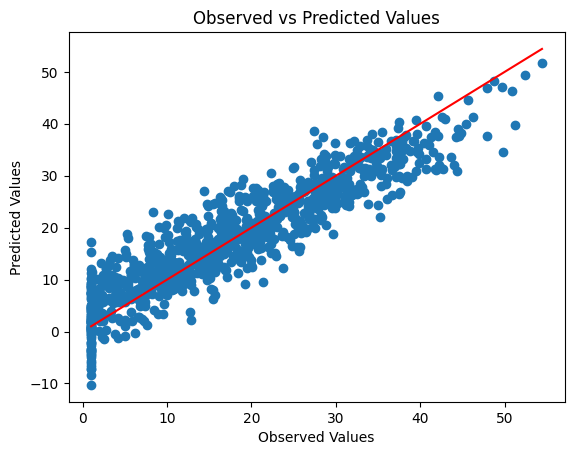

In [65]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_elastic)
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Observed vs Predicted Values")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

In [66]:
dataset_cleaned.sample(5)

,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
4679,24,4.48,1.00,1.18,2.23,2.34,9.23,10.29,35,342,0,1,4,31.10,42.91,29.48,13.29
2837,22,8.16,3.43,0.79,3.42,1.15,7.22,10.10,135,263,1,1,5,46.28,53.07,59.19,44.00
2698,19,7.11,1.90,0.30,3.98,2.44,6.23,7.61,82,348,0,0,8,39.44,45.50,54.52,31.19
4214,23,2.89,0.52,2.10,3.61,1.10,8.87,2.36,140,182,1,0,3,22.97,27.16,24.30,10.85
1984,16,3.56,0.04,0.95,2.83,1.25,7.74,7.38,60,42,1,1,10,32.79,61.34,41.92,20.72


In [67]:
dataset_cleaned[
    ['exercise_minutes',
     'caffeine_intake_mg',
     'focus_index',
     'burnout_level',
     'productivity_score',
     'exam_score']
].sample(5)

,exercise_minutes,caffeine_intake_mg,focus_index,burnout_level,productivity_score,exam_score
455,114,274,34.85,37.45,37.97,24.60
2788,146,153,36.14,77.19,43.80,15.97
2173,99,488,38.15,51.91,62.65,44.98
517,38,0,27.79,17.34,50.39,26.12
1819,81,200,14.87,48.34,18.38,1.00


In [69]:
print(dataset_cleaned['exam_score'].mean())

18.625932098765432


In [70]:
dataset_cleaned['performance_category'] = dataset_cleaned['exam_score'].apply(
    lambda x: 'High' if x > dataset_cleaned['exam_score'].mean() else 'Low'
)

print(dataset_cleaned[['exam_score', 'performance_category']].head())

   exam_score performance_category
0       50.16                 High
1        1.00                  Low
2       18.30                  Low
3        9.37                  Low
4       27.81                 High


In [71]:
X_class = dataset_cleaned.drop(['exam_score', 'performance_category'], axis=1)
y_class = dataset_cleaned['performance_category']

In [72]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=0
)

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c, y_train_c)

y_pred_log = log_model.predict(X_test_c)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test_c, y_pred_log))
print("Precision:", precision_score(y_test_c, y_pred_log, pos_label='High'))
print("Recall:", recall_score(y_test_c, y_pred_log, pos_label='High'))
print("F1 Score:", f1_score(y_test_c, y_pred_log, pos_label='High'))

Logistic Regression
Accuracy: 0.8652263374485597
Precision: 0.844789356984479
Recall: 0.8619909502262444
F1 Score: 0.8533034714445689


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [74]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_c, y_train_c)

y_pred_knn = knn.predict(X_test_c)

print("KNN")
print("Accuracy:", accuracy_score(y_test_c, y_pred_knn))
print("Precision:", precision_score(y_test_c, y_pred_knn, pos_label='High'))
print("Recall:", recall_score(y_test_c, y_pred_knn, pos_label='High'))
print("F1 Score:", f1_score(y_test_c, y_pred_knn, pos_label='High'))

KNN
Accuracy: 0.8343621399176955
Precision: 0.8157303370786517
Recall: 0.8212669683257918
F1 Score: 0.818489289740699


In [75]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_c, y_train_c)

y_pred_svm = svm.predict(X_test_c)

print("SVM")
print("Accuracy:", accuracy_score(y_test_c, y_pred_svm))
print("Precision:", precision_score(y_test_c, y_pred_svm, pos_label='High'))
print("Recall:", recall_score(y_test_c, y_pred_svm, pos_label='High'))
print("F1 Score:", f1_score(y_test_c, y_pred_svm, pos_label='High'))

SVM
Accuracy: 0.8580246913580247
Precision: 0.8408071748878924
Recall: 0.8484162895927602
F1 Score: 0.8445945945945946


In [76]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train_c, y_train_c)

y_pred_dt = dt.predict(X_test_c)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test_c, y_pred_dt))
print("Precision:", precision_score(y_test_c, y_pred_dt, pos_label='High'))
print("Recall:", recall_score(y_test_c, y_pred_dt, pos_label='High'))
print("F1 Score:", f1_score(y_test_c, y_pred_dt, pos_label='High'))

Decision Tree
Accuracy: 0.7993827160493827
Precision: 0.7714285714285715
Recall: 0.7941176470588235
F1 Score: 0.782608695652174


In [77]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)
rf.fit(X_train_c, y_train_c)

y_pred_rf = rf.predict(X_test_c)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test_c, y_pred_rf))
print("Precision:", precision_score(y_test_c, y_pred_rf, pos_label='High'))
print("Recall:", recall_score(y_test_c, y_pred_rf, pos_label='High'))
print("F1 Score:", f1_score(y_test_c, y_pred_rf, pos_label='High'))

Random Forest
Accuracy: 0.8580246913580247
Precision: 0.8392857142857143
Recall: 0.8506787330316742
F1 Score: 0.8449438202247191


In [78]:
print(dataset_cleaned['performance_category'].value_counts())

performance_category
Low     2531
High    2329
Name: count, dtype: int64


In [79]:
category_count = dataset_cleaned['performance_category'].value_counts()

print("Number of High performers:", category_count['High'])
print("Number of Low performers:", category_count['Low'])

Number of High performers: 2329
Number of Low performers: 2531


In [80]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nb = GaussianNB()
nb.fit(X_train_c, y_train_c)

y_pred_nb = nb.predict(X_test_c)

print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test_c, y_pred_nb))
print("Precision:", precision_score(y_test_c, y_pred_nb, pos_label='High'))
print("Recall:", recall_score(y_test_c, y_pred_nb, pos_label='High'))
print("F1 Score:", f1_score(y_test_c, y_pred_nb, pos_label='High'))

Naive Bayes
Accuracy: 0.8641975308641975
Precision: 0.8506787330316742
Recall: 0.8506787330316742
F1 Score: 0.8506787330316742


In [81]:
cluster_data = dataset_cleaned[['study_hours', 'focus_index', 'productivity_score']]

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

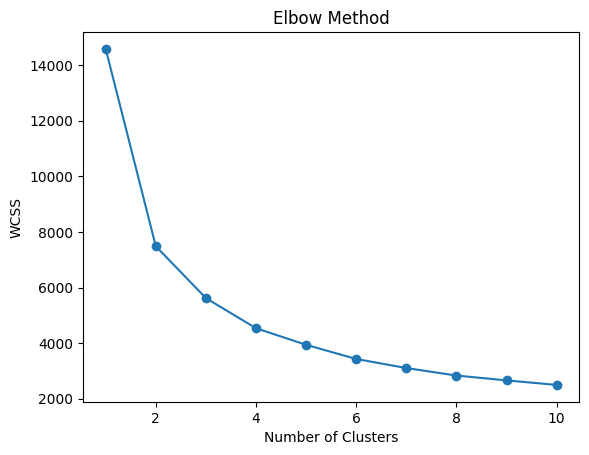

In [83]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [84]:
kmeans = KMeans(n_clusters=3, random_state=0)

dataset_cleaned['Cluster'] = kmeans.fit_predict(scaled_data)

print(dataset_cleaned['Cluster'].value_counts())

Cluster
1    2125
2    1401
0    1334
Name: count, dtype: int64


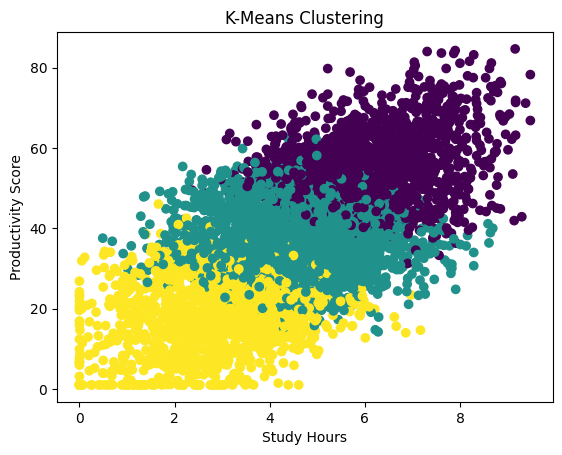

In [85]:
plt.scatter(
    dataset_cleaned['study_hours'],
    dataset_cleaned['productivity_score'],
    c=dataset_cleaned['Cluster'],
    cmap='viridis'
)

plt.xlabel("Study Hours")
plt.ylabel("Productivity Score")
plt.title("K-Means Clustering")
plt.show()